# Daily active users

Product-engagement metrics like daily active users have a recognizable shape: an underlying growth (or decay) trend, a strong weekly rhythm, and noise. `DailyActiveUsersGenerator` reproduces this for testing growth-analytics dashboards and anomaly detection on product metrics.

::: {.callout-note}
## The model

$$y_t = \text{base}\,(1 + g)^{\,d(t)} \cdot w(t) + \text{boost}_t + \varepsilon_t, \qquad \text{boost decays at } (1-\delta)$$

The level is `base_users * (1 + growth_rate)^day`, scaled on weekends by `weekend_factor` (1.2 for gaming, 0.8 otherwise). With probability `event_probability` per step an event adds `(impact - 1) * base` to a boost that decays geometrically at `event_decay_rate`, where `impact` is drawn between `event_impact_min` and `event_impact_max`. Proportional Gaussian noise (`noise_std`) is added and the result is clipped at zero.

Set `growth_rate_std` to perturb the growth rate per series, and `app_type` (`consumer`, `business`, `gaming`) to pick the defaults for a product profile.
:::

In [ ]:
import polars as pl
import matplotlib.pyplot as plt

from synforecast.generators import DailyActiveUsersGenerator

## App type

`app_type` sets the engagement profile, mainly through the weekend multiplier: a consumer app dips slightly at weekends, a B2B app drops sharply, and a gaming app rises. The seed and base level are shared.


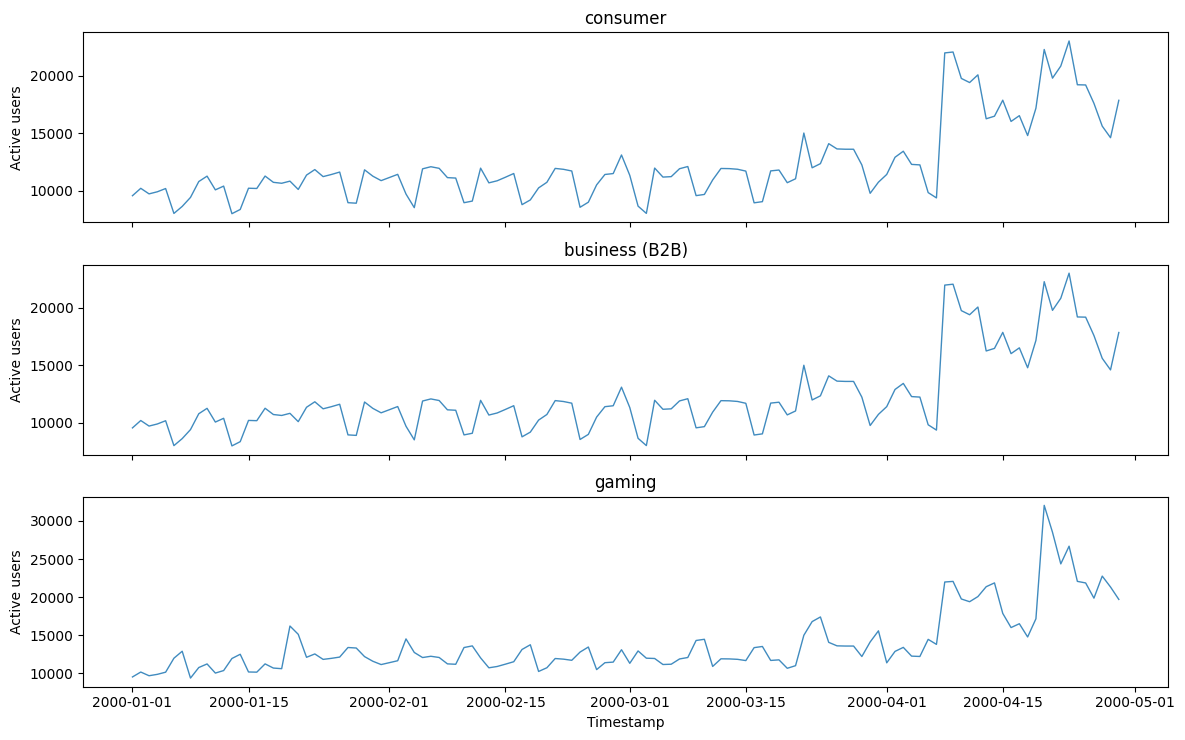

In [ ]:
consumer_df = DailyActiveUsersGenerator(
    engine="polars", min_length=120, max_length=120, freq="D",
    base_users=10000.0, growth_rate=0.002, app_type="consumer", seed=42,
).generate(n_series=1)

business_df = DailyActiveUsersGenerator(
    engine="polars", min_length=120, max_length=120, freq="D",
    base_users=10000.0, growth_rate=0.002, app_type="business", seed=42,
).generate(n_series=1)

gaming_df = DailyActiveUsersGenerator(
    engine="polars", min_length=120, max_length=120, freq="D",
    base_users=10000.0, growth_rate=0.002, app_type="gaming", seed=42,
).generate(n_series=1)

panels = [
    ("consumer", consumer_df),
    ("business (B2B)", business_df),
    ("gaming", gaming_df),
]
fig, axes = plt.subplots(3, 1, figsize=(12, 7.5), sharex=True)
for ax, (label, df) in zip(axes, panels):
    ax.plot(df["ds"].to_list(), df["y"].to_list(), alpha=0.85, linewidth=1)
    ax.set(ylabel="Active users", title=label)
axes[-1].set_xlabel("Timestamp")
plt.tight_layout()
plt.show()


## Analyzing event impact

Compare DAU on event days versus normal days to measure the lift from marketing events.

In [ ]:
event_days = consumer_df.filter(pl.col("event") == 1)
if len(event_days) > 0:
    print("Days when events occurred:")
    print(event_days)

    avg_event_day = consumer_df.filter(pl.col("event") == 1)["y"].mean()
    avg_normal_day = consumer_df.filter(pl.col("event") == 0)["y"].mean()
    print(f"\nAverage DAU on event days: {avg_event_day:,.0f}")
    print(f"Average DAU on normal days: {avg_normal_day:,.0f}")
    print(f"Event day lift: {(avg_event_day/avg_normal_day - 1)*100:.1f}%")

Days when events occurred:
shape: (4, 4)
┌───────────┬─────────────────────┬──────────────┬───────┐
│ unique_id ┆ ds                  ┆ y            ┆ event │
│ ---       ┆ ---                 ┆ ---          ┆ ---   │
│ cat       ┆ datetime[ns]        ┆ f64          ┆ i32   │
╞═══════════╪═════════════════════╪══════════════╪═══════╡
│ 0         ┆ 2000-01-20 00:00:00 ┆ 10816.372729 ┆ 1     │
│ 0         ┆ 2000-03-22 00:00:00 ┆ 15008.853745 ┆ 1     │
│ 0         ┆ 2000-04-08 00:00:00 ┆ 21994.846532 ┆ 1     │
│ 0         ┆ 2000-04-20 00:00:00 ┆ 22292.652679 ┆ 1     │
└───────────┴─────────────────────┴──────────────┴───────┘

Average DAU on event days: 17,528
Average DAU on normal days: 12,089
Event day lift: 45.0%


## Hourly active users

The generator also supports sub-daily frequencies like hourly data.

In [ ]:
hourly_params = {
    "min_length": 168,
    "max_length": 168,
    "freq": "h",
    "app_type": "consumer",
    "base_users": 10000.0,
    "event_probability": 0.01,
    "noise_std": 0.08,
    "seed": 42,
}
hourly_gen = DailyActiveUsersGenerator(engine="polars", **hourly_params)
hourly_df = hourly_gen.generate(n_series=1)

print(f"Generated {len(hourly_df)} hourly observations")
hourly_df.head(24)

Generated 168 hourly observations


unique_id,ds,y,event
cat,datetime[ns],f64,i32
"""0""",2000-01-01 00:00:00,9275.243589,0
"""0""",2000-01-01 01:00:00,10272.524421,0
"""0""",2000-01-01 02:00:00,9468.136049,0
"""0""",2000-01-01 03:00:00,9727.297606,0
"""0""",2000-01-01 04:00:00,10144.538427,0
…,…,…,…
"""0""",2000-01-01 19:00:00,13346.974807,1
"""0""",2000-01-01 20:00:00,12068.154452,0
"""0""",2000-01-01 21:00:00,10815.974473,0


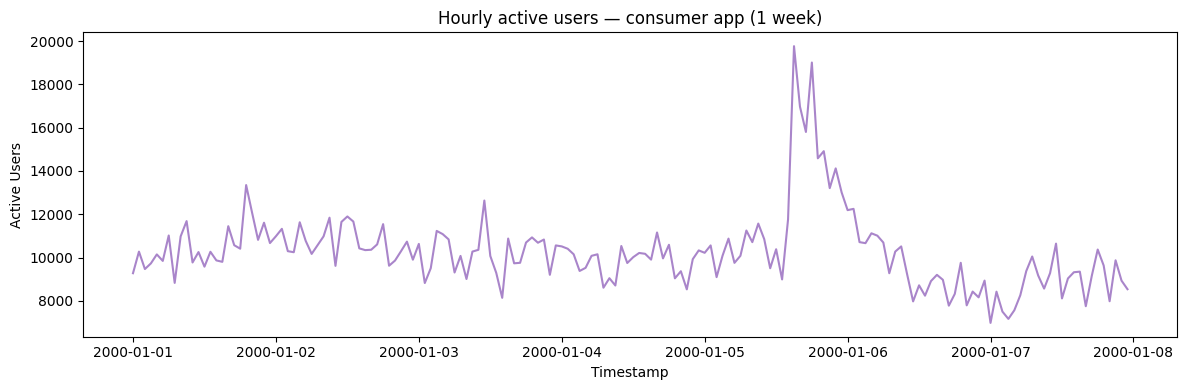

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(hourly_df["ds"].to_list(), hourly_df["y"].to_list(), alpha=0.8, color="C4")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Active Users")
ax.set_title("Hourly active users — consumer app (1 week)")
plt.tight_layout()
plt.show()

## Multiple products/apps

Generate DAU data for multiple products simultaneously and compare event distributions.

In [ ]:
multi_params = {
    "min_length": 30,
    "max_length": 30,
    "freq": "D",
    "app_type": "consumer",
    "base_users": 20000.0,
    "event_probability": 0.03,
    "seed": 42,
}
multi_gen = DailyActiveUsersGenerator(engine="polars", **multi_params)
multi_df = multi_gen.generate(n_series=5)

print(f"Generated 5 products with {len(multi_df)} total observations")
print("\nProduct 0 preview:")
print(multi_df.filter(pl.col("unique_id") == "0").head(10))

total_events = multi_df.group_by("unique_id").agg(pl.col("event").sum())
print("\nEvents per product:")
print(total_events)

Generated 5 products with 150 total observations

Product 0 preview:
shape: (10, 4)
┌───────────┬─────────────────────┬──────────────┬───────┐
│ unique_id ┆ ds                  ┆ y            ┆ event │
│ ---       ┆ ---                 ┆ ---          ┆ ---   │
│ cat       ┆ datetime[ns]        ┆ f64          ┆ i32   │
╞═══════════╪═════════════════════╪══════════════╪═══════╡
│ 0         ┆ 2000-01-01 00:00:00 ┆ 19094.054486 ┆ 0     │
│ 0         ┆ 2000-01-02 00:00:00 ┆ 20350.825855 ┆ 0     │
│ 0         ┆ 2000-01-03 00:00:00 ┆ 19354.510065 ┆ 0     │
│ 0         ┆ 2000-01-04 00:00:00 ┆ 19688.625437 ┆ 0     │
│ 0         ┆ 2000-01-05 00:00:00 ┆ 20221.064661 ┆ 0     │
│ 0         ┆ 2000-01-06 00:00:00 ┆ 15882.965767 ┆ 0     │
│ 0         ┆ 2000-01-07 00:00:00 ┆ 17069.908021 ┆ 0     │
│ 0         ┆ 2000-01-08 00:00:00 ┆ 18599.75721  ┆ 0     │
│ 0         ┆ 2000-01-09 00:00:00 ┆ 21305.138222 ┆ 0     │
│ 0         ┆ 2000-01-10 00:00:00 ┆ 22202.888052 ┆ 0     │
└───────────┴──────────────────

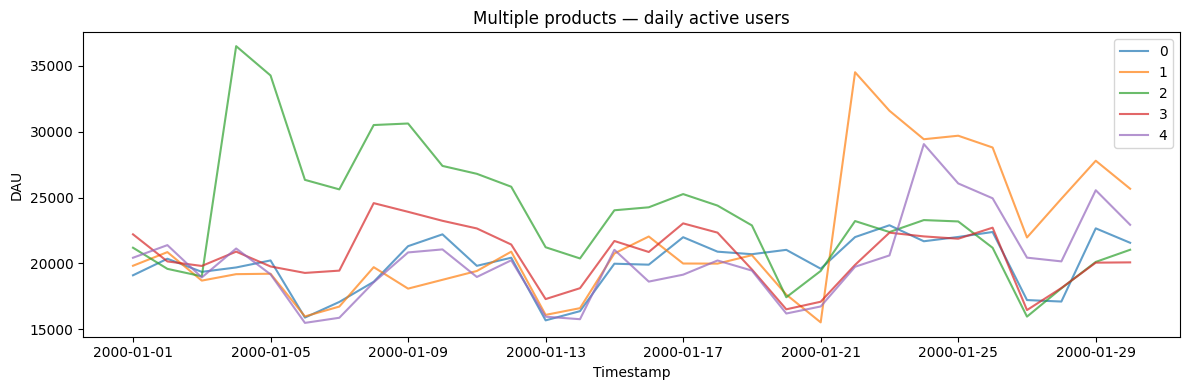

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
for uid in multi_df["unique_id"].unique().to_list():
    series = multi_df.filter(pl.col("unique_id") == uid)
    ax.plot(series["ds"].to_list(), series["y"].to_list(), label=uid, alpha=0.7)
ax.set_xlabel("Timestamp")
ax.set_ylabel("DAU")
ax.set_title("Multiple products — daily active users")
ax.legend()
plt.tight_layout()
plt.show()

## Custom column names

Customize the output column names to match your application's naming conventions.

In [ ]:
custom_params = {
    "min_length": 30,
    "max_length": 30,
    "freq": "D",
    "base_users": 15000.0,
    "event_probability": 0.05,
    "event_col": "marketing_campaign",
    "id_col": "product_id",
    "time_col": "date",
    "target_col": "dau",
    "seed": 42,
}
custom_gen = DailyActiveUsersGenerator(engine="polars", **custom_params)
custom_df = custom_gen.generate(n_series=1)

print(f"Columns: {custom_df.columns}")
custom_df.head(10)

Columns: ['product_id', 'date', 'dau', 'marketing_campaign']


product_id,date,dau,marketing_campaign
cat,datetime[ns],f64,i32
"""0""",2000-01-01 00:00:00,14320.540864,0
"""0""",2000-01-02 00:00:00,15263.119391,0
"""0""",2000-01-03 00:00:00,14515.882549,0
"""0""",2000-01-04 00:00:00,14766.469078,0
"""0""",2000-01-05 00:00:00,15165.798496,0
"""0""",2000-01-06 00:00:00,11912.224325,0
"""0""",2000-01-07 00:00:00,12802.431016,0
"""0""",2000-01-08 00:00:00,18654.126716,1
"""0""",2000-01-09 00:00:00,18991.33087,0


::: {.callout-tip}
## Related generators

- [Clickstream](/synforecast/docs/generators/domain/clickstream.html) — the sessionized activity beneath engagement metrics.
- [Seasonal](/synforecast/docs/generators/statistical/seasonal.html) — the weekly rhythm in isolation.

Full parameters are in the [generator reference](https://github.com/Nixtla/synforecast/blob/main/GENERATORS.md).
:::